In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
from phisat2.data_loaders import build_datamodule
from phisat2.tasks import resolve_task_spec
from phisat2.utils.seed import seed_everything
from phisat2.utils.visualization import visualize_triplet_batch

In [3]:
ROOT_DIR = "/lustre/home/u10010021/phisat2/data/triplets"
BATCH_SIZE = 4              
SEED = 42

In [4]:
seed_everything(SEED)

spec = resolve_task_spec("pretrain_reconstruction", "triplets")

datamodule = build_datamodule(
    "triplets",
    root_dir=ROOT_DIR,
    spec=spec,
    batch_size=BATCH_SIZE,
    num_workers=2,
    seed=SEED,
    crop_size=256,
    fast_dev_run=False
)
datamodule.setup(stage="test")
test_loader = datamodule.test_dataloader()

In [5]:
for i, batch in enumerate(test_loader):
    if i >= 20:
        break

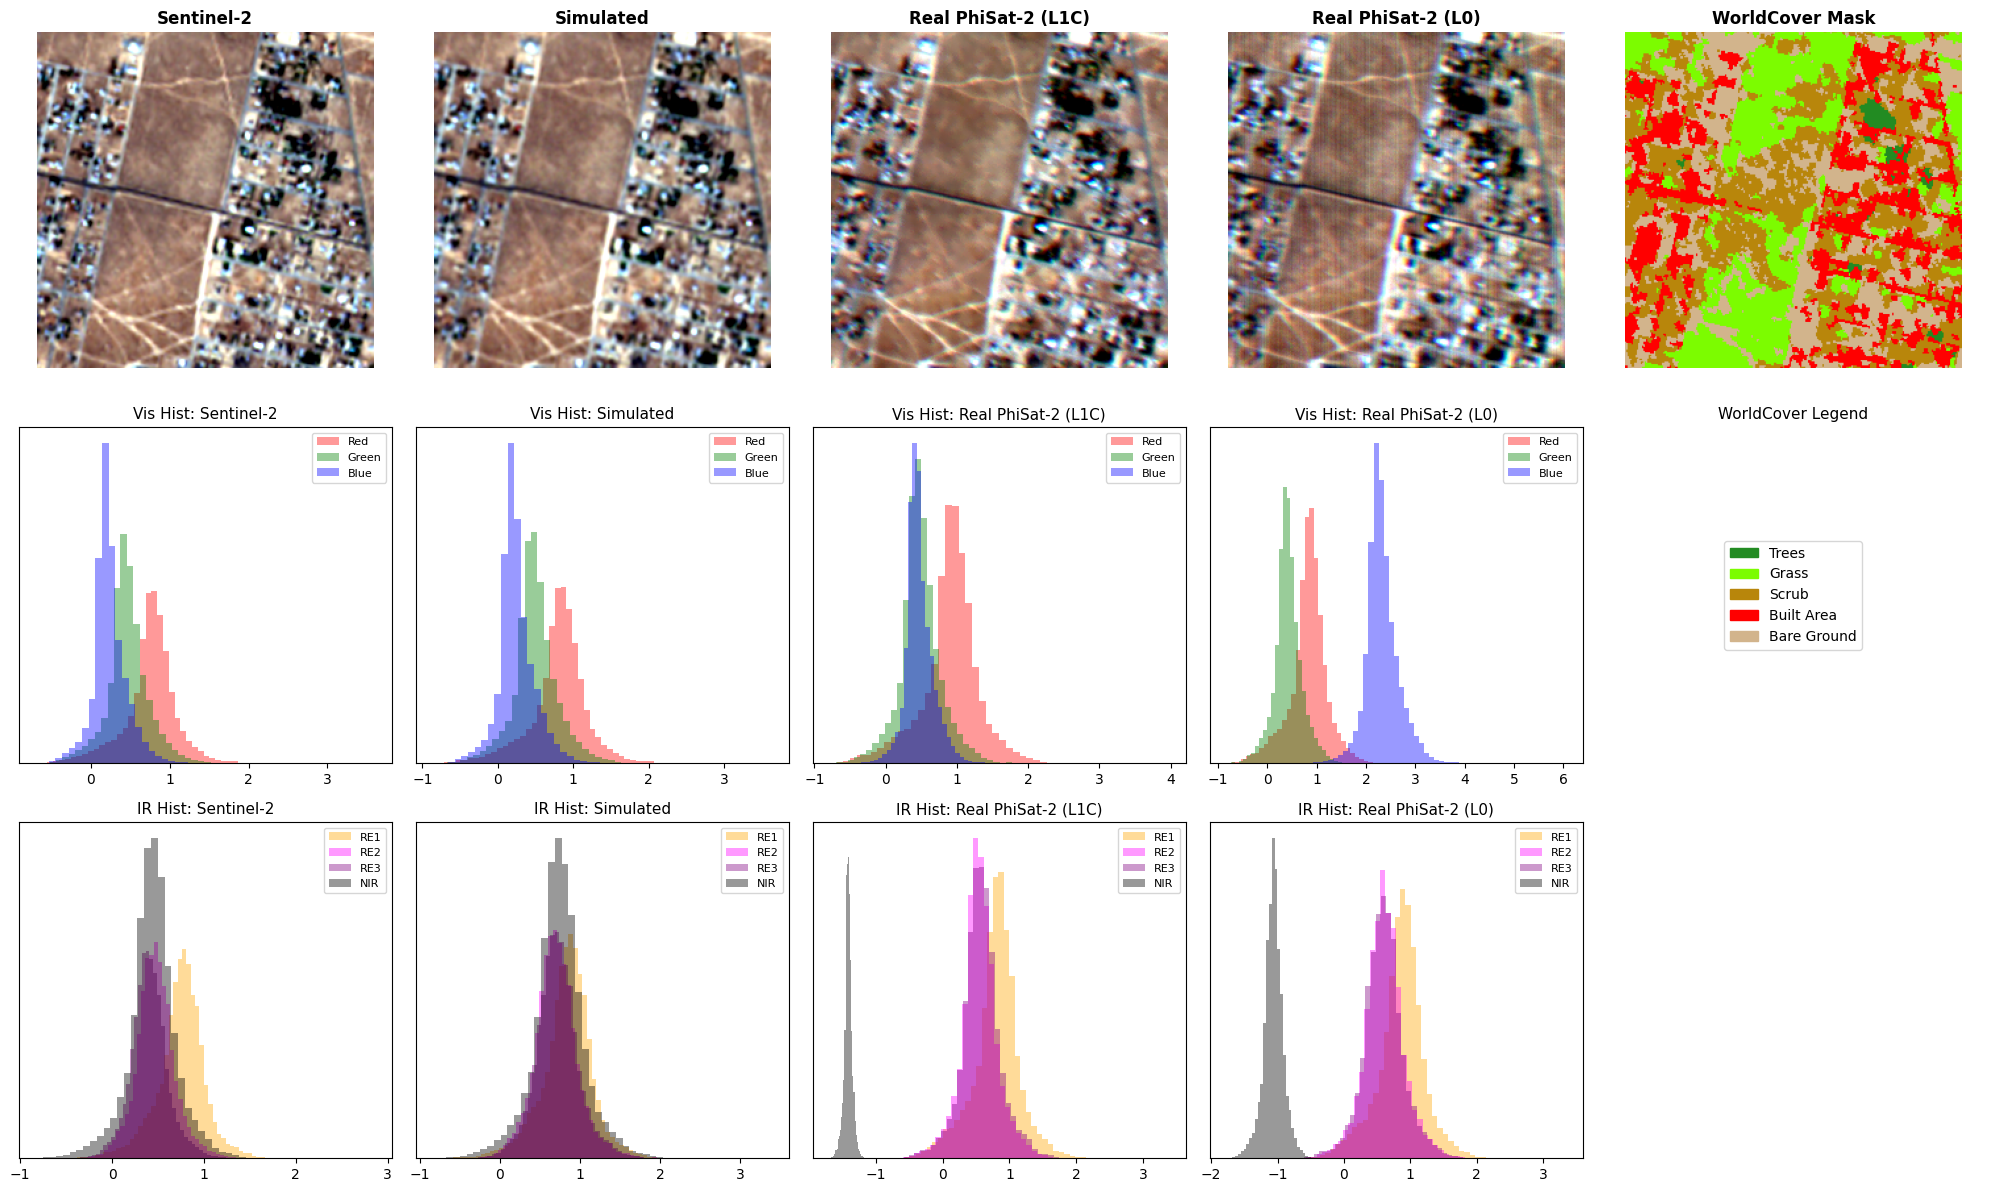

In [6]:
visualize_triplet_batch(batch, idx=1, show_cloud=False, show_worldcover=True)#,zoom_box=(100, 100, 150, 150))

In [7]:
batch["real_L0"]

tensor([[[[-1.1674e-01, -9.4801e-02,  7.7266e-02,  ...,  1.9044e-01,
            2.5049e-01,  2.0314e-01],
          [-1.3522e-01, -1.5601e-01,  4.5130e-03,  ...,  1.2577e-01,
            1.3847e-01,  3.6848e-02],
          [-1.5485e-01, -9.1337e-02, -4.9763e-02,  ..., -4.7256e-03,
           -4.7256e-03, -1.1790e-01],
          ...,
          [ 3.6020e-01,  3.7752e-01,  4.0408e-01,  ..., -1.1212e-01,
            6.8028e-02,  7.9576e-02],
          [ 3.9484e-01,  3.9138e-01,  4.3988e-01,  ..., -1.2021e-01,
            1.1442e-02,  3.1074e-02],
          [ 3.8560e-01,  4.0639e-01,  4.4103e-01,  ..., -1.6986e-01,
           -3.1286e-02, -6.7086e-02]],

         [[ 1.9832e+00,  2.0596e+00,  2.0809e+00,  ...,  1.9130e+00,
            1.9313e+00,  1.7908e+00],
          [ 1.9649e+00,  2.1176e+00,  2.1420e+00,  ...,  1.8885e+00,
            1.8641e+00,  1.8641e+00],
          [ 1.9679e+00,  2.2001e+00,  2.1909e+00,  ...,  1.8091e+00,
            1.8366e+00,  1.7328e+00],
          ...,
     

🎲 Paire sélectionnée : pair_000002256_20250514115751_20250514115754_B268FF55
🎲 Patch sélectionné : r000000_c001792.tif


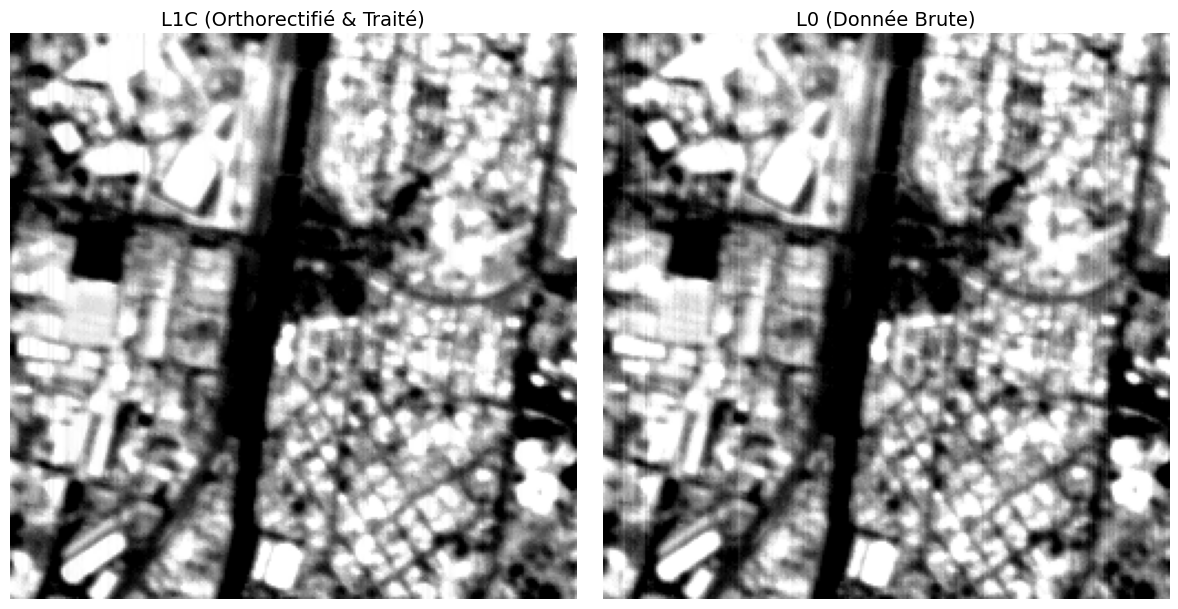

In [24]:
%matplotlib inline
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path

# ==========================================
# PARAMÈTRES
# ==========================================
L1C_DIR = Path("/lustre/home/u10010021/phisat2/data/triplets/pairs")
L0_DIR = Path("/lustre/scratch/1001/depastor/triplet_patchs_L0")

# ==========================================
# SÉLECTION ALÉATOIRE
# ==========================================
# 1. On liste tous les dossiers de paires dispos dans L0
l0_pairs = [d for d in L0_DIR.iterdir() if d.is_dir()]
if not l0_pairs:
    raise ValueError("❌ Aucun dossier de paire trouvé dans L0_DIR.")

# On en prend un au hasard
random_pair = random.choice(l0_pairs)
PAIR_NAME = random_pair.name

# 2. On liste tous les patchs dans cette paire et on en pioche un
l0_patches = list(random_pair.glob("r*_c*.tif"))
if not l0_patches:
    raise ValueError(f"❌ Aucun patch trouvé dans {random_pair.name}")

random_patch = random.choice(l0_patches)
PATCH_NAME = random_patch.name

print(f"🎲 Paire sélectionnée : {PAIR_NAME}")
print(f"🎲 Patch sélectionné : {PATCH_NAME}")

# ==========================================
# FONCTION DE NORMALISATION (1 Bande)
# ==========================================
def read_and_normalize(filepath, band_idx=0, pmin=10, pmax=90):
    """Lit une seule bande d'un raster et normalise le contraste pour l'affichage."""
    with rasterio.open(filepath) as src:
        # Lecture de la bande spécifique (retourne un array 2D)
        data = src.read(band_idx).astype(np.float32)

    # Normalisation par percentile
    vmin, vmax = np.percentile(data, (pmin, pmax))
    
    # Évite la division par zéro si l'image est toute noire
    if vmax - vmin > 0:
        img_norm = np.clip((data - vmin) / (vmax - vmin), 0, 1)
    else:
        img_norm = np.zeros_like(data)

    return img_norm

# ==========================================
# AFFICHAGE
# ==========================================
l1c_path = L1C_DIR / PAIR_NAME / "lightglue_coregistration" / "tiles" / "phisat2" / PATCH_NAME
l0_path = L0_DIR / PAIR_NAME / PATCH_NAME

if not l1c_path.exists():
    print(f"❌ Patch L1C introuvable : {l1c_path}")
elif not l0_path.exists():
    print(f"❌ Patch L0 introuvable : {l0_path}")
else:
    # Chargement et traitement des images (Bande 3 = Rouge)
    img_l1c = read_and_normalize(l1c_path, band_idx=1)
    img_l0 = read_and_normalize(l0_path, band_idx=1)

    # Affichage côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(img_l1c, cmap='gray')
    axes[0].set_title("L1C (Orthorectifié & Traité)", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(img_l0, cmap='gray')
    axes[1].set_title("L0 (Donnée Brute)", fontsize=14)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()